DATA




In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)
n = 2500  # 2500 synthetic African women

# Generate measurements based on African women anthropometric research
# Pandarum et al. and ABD Initiative informed these distributions
# Measurement are in cm

bust   = np.random.normal(96, 10, n).clip(75, 130)
waist  = np.random.normal(78, 10, n).clip(58, 110)
hip    = np.random.normal(102, 11, n).clip(80, 140)
height = np.random.normal(162, 7, n).clip(145, 185)

# Create dataframe
df = pd.DataFrame({
    'bust'  : bust.round(1),
    'waist' : waist.round(1),
    'hip'   : hip.round(1),
    'height': height.round(1)
})

# Save as CSV
df.to_csv('african_women_measurements.csv', index=False)

print('Synthetic dataset created successfully')
print('Rows:', len(df))
print()
print('Bust min:', round(df['bust'].min(),1), ' max:', round(df['bust'].max(),1))
print('Waist min:', round(df['waist'].min(),1), ' max:', round(df['waist'].max(),1))
print('Hip min:', round(df['hip'].min(),1), ' max:', round(df['hip'].max(),1))
print('Height min:', round(df['height'].min(),1), ' max:', round(df['height'].max(),1))
df.head()

Synthetic dataset created successfully
Rows: 2500

Bust min: 75.0  max: 130.0
Waist min: 58.0  max: 110.0
Hip min: 80.0  max: 140.0
Height min: 145.0  max: 185.0


,bust,waist,hip,height
0,101.0,83.7,97.3,174.1
1,94.6,87.7,97.0,162.9
2,102.5,74.7,82.2,167.3
3,111.2,71.9,98.4,162.7
4,93.7,67.1,110.1,157.3


EDA

In [ ]:
df.head()

,bust,waist,hip,height
0,101.0,83.7,97.3,174.1
1,94.6,87.7,97.0,162.9
2,102.5,74.7,82.2,167.3
3,111.2,71.9,98.4,162.7
4,93.7,67.1,110.1,157.3


In [ ]:
df.tail()

,bust,waist,hip,height
2495,104.1,77.5,96.5,171.1
2496,93.2,85.1,96.3,148.0
2497,93.2,109.1,125.4,157.1
2498,103.9,86.1,80.0,165.5
2499,99.4,69.5,100.0,166.5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   bust    2500 non-null   float64
 1   waist   2500 non-null   float64
 2   hip     2500 non-null   float64
 3   height  2500 non-null   float64
dtypes: float64(4)
memory usage: 78.3 KB


In [ ]:
df.describe()

,bust,waist,hip,height
count,2500.000000,2500.000000,2500.000000,2500.000000
mean,96.390880,77.874960,101.782040,162.086680
std,9.683147,9.842414,11.030996,6.909661
min,75.000000,58.000000,80.000000,145.000000
25%,89.700000,70.900000,94.100000,157.400000
50%,96.300000,77.900000,101.550000,162.100000
75%,102.800000,84.500000,109.500000,166.700000
max,130.000000,110.000000,140.000000,185.000000


In [ ]:
df.shape

(2500, 4)

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isnull().sum()

,0
bust,0
waist,0
hip,0
height,0


Assign Body Type Labels;
(Classifying body type asper body measurement)

In [ ]:
def classify_body_type(row):
    bust  = row['bust']
    waist = row['waist']
    hip   = row['hip']

    whr           = waist / hip
    diff_bust_hip = bust - hip
    diff_hip_bust = hip  - bust

    if abs(diff_bust_hip) <= 5 and whr < 0.75:
        return 'Hourglass'
    if diff_bust_hip > 5:
        return 'Inverted Triangle'
    if diff_hip_bust > 5 and whr < 0.80:
        return 'Pear'
    if whr >= 0.85 or waist >= hip or waist >= bust:
        return 'Apple'
    return 'Rectangle'

df['body_type'] = df.apply(classify_body_type, axis=1)

print('Body types assigned')
print(df['body_type'].value_counts())

Body types assigned
body_type
Pear                 974
Inverted Triangle    610
Apple                390
Rectangle            309
Hourglass            217
Name: count, dtype: int64


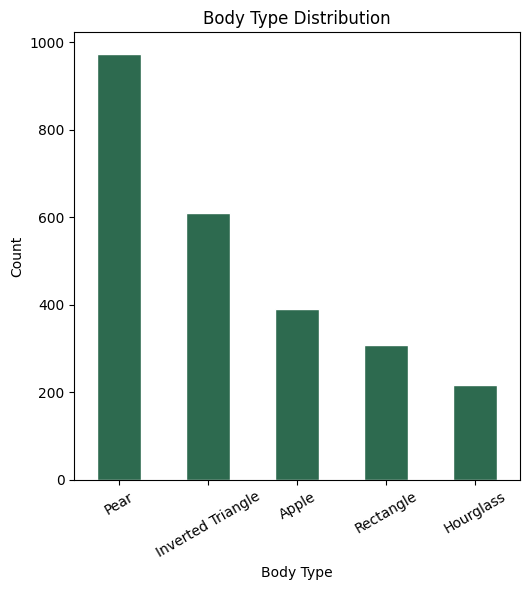

In [ ]:
# Plot distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)

df['body_type'].value_counts().plot(kind='bar', color='#2D6A4F', edgecolor='white')
plt.title('Body Type Distribution')
plt.xlabel('Body Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Features

In [ ]:
# Add ratio features
df['whr'] = df['waist'] / df['hip']
df['bhr'] = df['bust']  / df['hip']
df['wbr'] = df['waist'] / df['bust']

X = df[['bust', 'waist', 'hip', 'height', 'whr', 'bhr', 'wbr']]
y = df['body_type']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (2500, 7)
y shape: (2500,)


In [ ]:
# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print('Classes:', list(le.classes_))

Classes: ['Apple', 'Hourglass', 'Inverted Triangle', 'Pear', 'Rectangle']


Spilt Data

In [ ]:
#split data
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.30, random_state=42, stratify=y_encoded)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print('Train:', len(X_train))
print('Val:  ', len(X_val))
print('Test: ', len(X_test))

Train: 1750
Val:   375
Test:  375


Smote

In [ ]:
# Balance body type classes
# Creates synthetic records for underrepresented body types
# Applied on training data only — never on test or validation data

from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print('Training rows after SMOTE:', len(X_train))

Training rows after SMOTE: 3410


Scale

In [ ]:
# Bust=96cm and Height=162cm are very different scales
# StandardScaler puts all measurements on the same scale
# so no single measurement dominates the model

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Learn the scale from training data and apply it
X_train = scaler.fit_transform(X_train)


# Apply the same scale to validation and test
# We do NOT fit again — only transform
X_val  = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print('Scaling done')

Scaling done


Baseline Support Vector Machine (SVM)

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score

svm_baseline = SVC(kernel='linear', random_state=42)
svm_baseline.fit(X_train, y_train)

y_pred = svm_baseline.predict(X_val)

print('Baseline Accuracy:', round(accuracy_score(y_val, y_pred) * 100, 2), '%')
print('Baseline F1 Score:', round(f1_score(y_val, y_pred, average='weighted'), 4))
print('Benchmark to beat: 89.66%')

Baseline Accuracy: 94.93 %
Baseline F1 Score: 0.9506
Benchmark to beat: 89.66%


GridSearchCV(Tuning)

In [ ]:
from sklearn.model_selection import GridSearchCV

# GridSearchCV automatically tests multiple SVM settings
# and finds the best combination for your data

# Settings to test:
# kernel — shape of decision boundary (linear, curve, polynomial)
# C      — how strict the model is (low=flexible, high=strict)
# gamma  — how far each data point influences the boundary
param_grid = {
    'kernel': ['linear', 'rbf', 'poly'],
    'C'     : [0.1, 1, 10, 100],
    'gamma' : ['scale', 'auto']
}

# Run 24 combinations × 5 folds = 120 experiments automatically
# cv=5          — tests each combination 5 times for reliability
# f1_weighted   — picks best result based on F1 score not just accuracy
# n_jobs=-1     — uses all computer processors to run faster
# verbose=1     — prints progress so you can see it working
grid = GridSearchCV(SVC(random_state=42), param_grid,
                    cv=5, scoring='f1_weighted', n_jobs=-1, verbose=1)

# Train all 120 experiments and pick the winner
grid.fit(X_train, y_train)

# Print the winning settings and its F1 score
print('Best settings:', grid.best_params_)
print('Best CV F1:   ', round(grid.best_score_, 4))

Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best settings: {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV F1:    0.9859


Evaluate Best Model

In [ ]:
# Retrieve the best SVM model found by GridSearchCV
best_svm = grid.best_estimator_

# Use the best model to predict body types on validation data
y_pred_best = best_svm.predict(X_val)

# Calculate how many predictions were correct out of 100%
acc = accuracy_score(y_val, y_pred_best)

# Calculate F1 score — more reliable than accuracy for multiple classes
f1  = f1_score(y_val, y_pred_best, average='weighted')

# Print results
print('Tuned Accuracy:', round(acc * 100, 2), '%')
print('Tuned F1 Score:', round(f1, 4))

# Check if we beat the published benchmark of 89.66%
if acc > 0.8966:
    print('Benchmark BEATEN!')
else:
    print('Below benchmark')

Tuned Accuracy: 94.93 %
Tuned F1 Score: 0.9501
Benchmark BEATEN!


Final Test & Confusion Matrix

In [ ]:
# Import evaluation tools
# classification_report — shows precision, recall, F1 per body type
# confusion_matrix      — shows where the model got it right and wrong
# ConfusionMatrixDisplay — draws the confusion matrix as a visual grid
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Final exam — predict on test data the model has never seen before
# This is the most honest measure of how well your model performs
y_pred_test = best_svm.predict(X_test)

# Overall accuracy — percentage of correct predictions out of 100%
print('Final Accuracy:', round(accuracy_score(y_test, y_pred_test) * 100, 2), '%')

# Overall F1 score — balances precision and recall across all 5 body types
print('Final F1 Score:', round(f1_score(y_test, y_pred_test, average='weighted'), 4))

print()

# Per class report — shows how well the model performed on each body type
# Precision — of all predicted Hourglass, how many were actually Hourglass
# Recall    — of all actual Hourglass, how many did the model correctly find
# F1        — balance between precision and recall per body type
print(classification_report(y_test, y_pred_test, target_names=le.classes_))

Final Accuracy: 95.47 %
Final F1 Score: 0.9553

                   precision    recall  f1-score   support

            Apple       0.96      0.93      0.95        59
        Hourglass       0.86      0.94      0.90        32
Inverted Triangle       0.98      0.98      0.98        92
             Pear       0.99      0.95      0.97       146
        Rectangle       0.86      0.96      0.91        46

         accuracy                           0.95       375
        macro avg       0.93      0.95      0.94       375
     weighted avg       0.96      0.95      0.96       375



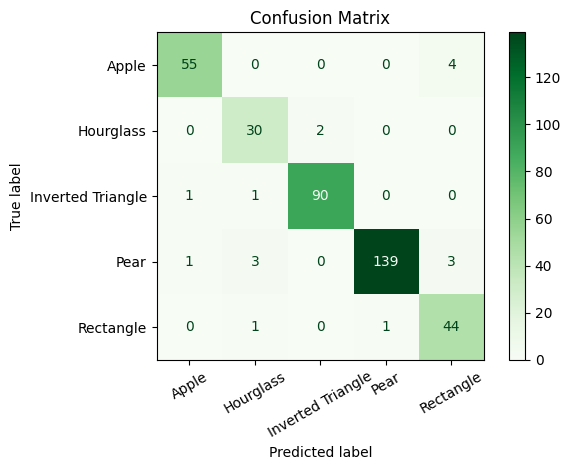

In [ ]:
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_test),
    display_labels=le.classes_
).plot(cmap='Greens')
plt.title('Confusion Matrix')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Cross Validation

In [ ]:
# Import cross validation tool
from sklearn.model_selection import cross_val_score

# Cross validation checks if your model is consistent
# It splits training data into 10 equal parts
# Trains on 9 parts and tests on 1 part — repeats 10 times
# This confirms the model is not just lucky on one split
cv_scores = cross_val_score(
    best_svm,          # the model to test
    X_train,           # training features
    y_train,           # training labels
    cv=10,             # split into 10 parts
    scoring='f1_weighted'  # measure using F1 score
)

# Average F1 score across all 10 rounds
# Higher is better — should be close to your test F1
print('CV Mean F1:', round(cv_scores.mean(), 4))

# How consistent the model is across all 10 rounds
# Low std dev = stable model, high std dev = inconsistent model
print('CV Std Dev:', round(cv_scores.std(), 4))

CV Mean F1: 0.9856
CV Std Dev: 0.0084


Save Model

In [ ]:
import joblib

joblib.dump(best_svm, 'svm_model.pkl')
joblib.dump(scaler,   'scaler.pkl')
joblib.dump(le,       'label_encoder.pkl')

print('Model saved successfully')

Model saved successfully


Outfit Recommendation Engine

In [ ]:
OUTFITS = {
    'Hourglass': {
        'description': 'Balanced bust and hip with a defined waist.',
        'goal'       : 'Highlight your natural waist and celebrate your curves.',
        'best_fits'  : ['Wrap dresses', 'Belted outfits', 'Fit-and-flare styles', 'Bodycon dresses', 'High-waisted trousers', 'Ankara wrap skirts'],
        'avoid'      : ['Boxy oversized styles', 'Drop-waist designs'],
        'neckline'   : 'V-neck, sweetheart, scoop',
        'fabric'     : 'Soft draping fabrics like jersey, silk, chiffon',
        'african'    : 'Ankara wrap dress or off-shoulder Iro and Buba'
    },
    'Pear': {
        'description': 'Hips wider than bust — very common African female silhouette.',
        'goal'       : 'Balance upper and lower body by drawing attention upward.',
        'best_fits'  : ['A-line skirts', 'Peplum tops', 'Off-shoulder tops', 'Wide-leg trousers', 'Ankara peplum tops'],
        'avoid'      : ['Tight pencil skirts', 'Bold patterns on lower half'],
        'neckline'   : 'Boat neck, off-shoulder, square neck',
        'fabric'     : 'Structured fabrics on top, flowing on bottom',
        'african'    : 'Peplum Ankara blouse with a plain dark wrapper skirt'
    },
    'Apple': {
        'description': 'Fuller midsection with slimmer hips and legs.',
        'goal'       : 'Draw attention away from midsection and elongate the torso.',
        'best_fits'  : ['Empire waist dresses', 'Flowy tunics', 'A-line tops', 'Structured blazers', 'Kaftan styles'],
        'avoid'      : ['Belted styles at the waist', 'Clingy fabrics', 'Cropped tops'],
        'neckline'   : 'V-neck, deep scoop',
        'fabric'     : 'Flowy draping fabrics that skim without clinging',
        'african'    : 'Kaftan or Boubou in bold Ankara or Adire print'
    },
    'Rectangle': {
        'description': 'Bust, waist, and hip measurements are similar.',
        'goal'       : 'Create the illusion of curves and a defined waist.',
        'best_fits'  : ['Ruffled tops', 'Peplum styles', 'Belted outfits', 'Fit-and-flare dresses', 'Ankara co-ord sets with a belt'],
        'avoid'      : ['Boxy shapeless styles', 'Drop-waist cuts'],
        'neckline'   : 'Any neckline — embellished or statement works best',
        'fabric'     : 'Structured fabrics that add shape',
        'african'    : 'Structured Aso-Oke or Ankara co-ord set with a bold belt'
    },
    'Inverted Triangle': {
        'description': 'Shoulders and bust wider than hips.',
        'goal'       : 'Balance broad shoulders by adding volume to lower body.',
        'best_fits'  : ['A-line and flared skirts', 'Wide-leg trousers', 'Scoop neck tops', 'Full skirts with plain fitted tops'],
        'avoid'      : ['Off-shoulder tops', 'Shoulder pads', 'Slim straight-leg trousers'],
        'neckline'   : 'Scoop neck, round neck, V-neck',
        'fabric'     : 'Plain minimal fabric on top, bold textured fabric on bottom',
        'african'    : 'Plain fitted top with a voluminous Ankara bubble skirt'
    }
}

print('Outfit recommendation engine ready')

Outfit recommendation engine ready


Full Pipeline Function

In [ ]:
def predict_and_recommend(bust, waist, hip, height):
    # Calculate ratios
    whr = waist / hip
    bhr = bust  / hip
    wbr = waist / bust

    # Scale input
    features = scaler.transform([[bust, waist, hip, height, whr, bhr, wbr]])

    # Stage 1: predict body type
    pred      = best_svm.predict(features)[0]
    body_type = le.inverse_transform([pred])[0]

    # Stage 2: get outfit recommendations
    rec = OUTFITS[body_type]

    return body_type, rec

print('Pipeline ready')

Pipeline ready


Test the Full Pipeline

In [ ]:
body_type, rec = predict_and_recommend(
    bust=96, waist=72, hip=102, height=162)

print('Predicted Body Type:', body_type)
print()
print('Description  :', rec['description'])
print('Goal         :', rec['goal'])
print('Best Fits    :', rec['best_fits'])
print('Avoid        :', rec['avoid'])
print('Neckline     :', rec['neckline'])
print('Fabric       :', rec['fabric'])
print('African Style:', rec['african'])

Predicted Body Type: Pear

Description  : Hips wider than bust — very common African female silhouette.
Goal         : Balance upper and lower body by drawing attention upward.
Best Fits    : ['A-line skirts', 'Peplum tops', 'Off-shoulder tops', 'Wide-leg trousers', 'Ankara peplum tops']
Avoid        : ['Tight pencil skirts', 'Bold patterns on lower half']
Neckline     : Boat neck, off-shoulder, square neck
Fabric       : Structured fabrics on top, flowing on bottom
African Style: Peplum Ankara blouse with a plain dark wrapper skirt


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


For Interface building


In [ ]:
# After training and saving the model
# this step downloads the three saved model files
# from Google Colab to your local computer.

# These files are required to run the Streamlit web application.
# Without them, the app cannot make predictions.

# svm_model.pkl    — the trained SVM classifier (Stage 1)
# scaler.pkl       — the StandardScaler used during training
# label_encoder.pkl — maps numeric predictions back to body type names

import pickle
import joblib

best_svm = joblib.load('svm_model.pkl')
scaler   = joblib.load('scaler.pkl')
le       = joblib.load('label_encoder.pkl')

with open('svm_model.pkl', 'wb') as f:
    pickle.dump(best_svm, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

print('Done')

from google.colab import files

# Download the trained SVM model
files.download('svm_model.pkl')

# Download the fitted feature scaler
files.download('scaler.pkl')

# Download the fitted label encoder
files.download('label_encoder.pkl')

print('All model files downloaded successfully')


Done


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All model files downloaded successfully
